# K-Means Clustering Implementation

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.datasets import make_blobs
%matplotlib inline

## Create a sample dataset

In [2]:
# 1000 points, 3 groups, 2 features
X, y = make_blobs(n_samples=1000, centers=3, n_features=2, random_state=23)

In [3]:
X

array([[-5.37039106,  3.47555168],
       [ 5.84161203, -3.98182959],
       [ 1.76127766,  9.39696306],
       ...,
       [ 6.14147823, -5.75491603],
       [-5.45330839,  1.75599573],
       [-0.21966953,  8.72922042]], shape=(1000, 2))

In [4]:
y

array([2, 1, 0, 2, 1, 0, 2, 1, 2, 0, 0, 0, 2, 0, 1, 2, 2, 2, 1, 1, 0, 1,
       2, 2, 0, 0, 1, 2, 0, 0, 0, 2, 1, 2, 1, 0, 1, 2, 2, 1, 0, 1, 1, 2,
       2, 1, 0, 2, 1, 1, 2, 2, 1, 2, 0, 2, 0, 2, 2, 2, 1, 0, 2, 2, 2, 2,
       2, 2, 0, 2, 2, 0, 0, 1, 1, 2, 0, 0, 1, 1, 0, 2, 1, 2, 2, 0, 1, 2,
       1, 2, 0, 1, 0, 0, 2, 0, 2, 1, 2, 2, 0, 2, 1, 2, 2, 2, 2, 0, 1, 1,
       0, 2, 2, 2, 2, 2, 2, 1, 2, 0, 0, 0, 1, 1, 1, 1, 0, 0, 2, 0, 2, 1,
       0, 0, 2, 1, 1, 2, 1, 2, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 2, 0, 0,
       1, 1, 1, 1, 2, 1, 2, 1, 0, 2, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 2,
       0, 0, 2, 1, 1, 2, 0, 1, 2, 1, 0, 1, 1, 1, 1, 1, 1, 2, 2, 1, 2, 0,
       2, 2, 2, 0, 1, 1, 0, 0, 1, 0, 2, 0, 0, 1, 0, 2, 0, 1, 1, 0, 0, 1,
       1, 2, 0, 2, 0, 1, 2, 2, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 2, 1, 2, 1, 0, 2, 0, 0, 2, 2, 0, 1, 0, 1, 1, 2, 1, 0, 0,
       1, 0, 0, 0, 1, 2, 0, 2, 0, 1, 0, 1, 2, 2, 2, 0, 1, 0, 1, 2, 2, 0,
       0, 0, 0, 0, 0, 2, 1, 1, 2, 0, 2, 2, 1, 1, 1,

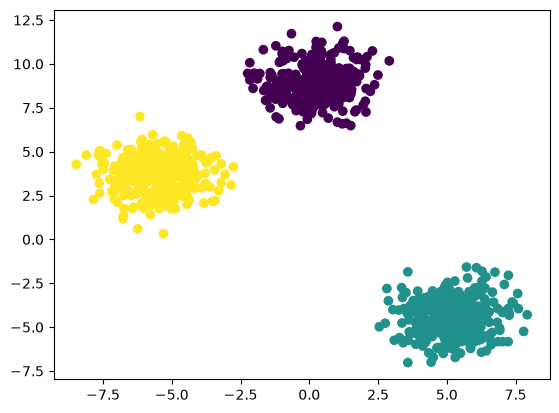

In [5]:
# Visualize the data
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

## Train-test split and feature scaling

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=22)

In [8]:
# Standardize features (mean 0, std 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Elbow method to choose K

In [9]:
from sklearn.cluster import KMeans

In [10]:
# KMeans parameters:
# n_clusters   -> number of clusters (K) to form
# init         -> how starting centroids are picked ('k-means++' spreads them out smartly)
# n_init       -> run K-Means this many times with different starts, keep the best
# random_state -> fixes randomness so results are same every run
# WCSS = sum of squared distances to the nearest centroid
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=21)
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [11]:
wcss

[1339.9999999999998,
 347.62282658382975,
 56.416767165853145,
 49.13442165874855,
 41.99276394501732,
 35.21491136245615,
 31.232718853264107,
 27.668438156355286,
 24.19309379288691,
 22.477957155217805]

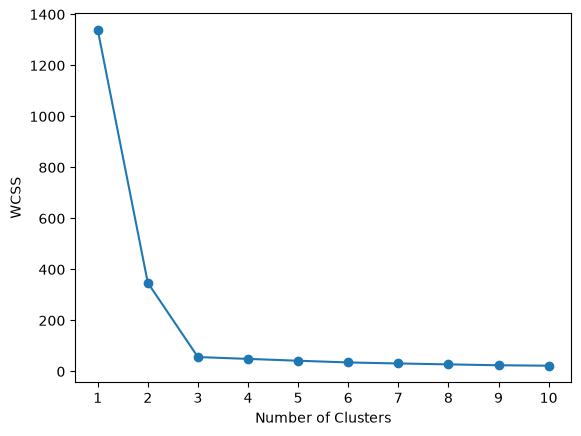

In [12]:
# Plot elbow curve
plt.plot(range(1, 11), wcss, marker="o")
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

## Train the model with K = 3

In [13]:
# KMeans parameters:
# n_clusters   -> number of clusters (K) to form
# init         -> how starting centroids are picked ('k-means++' spreads them out smartly)
# n_init       -> run K-Means this many times with different starts, keep the best
# random_state -> fixes randomness so results are same every run
kmeans = KMeans(n_clusters=3, init="k-means++", n_init=10, random_state=42)
kmeans.fit_predict(X_train_scaled)

array([2, 1, 1, 0, 1, 1, 1, 2, 2, 2, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 2, 1,
       1, 2, 1, 1, 1, 0, 1, 0, 0, 0, 2, 2, 2, 1, 1, 2, 1, 0, 1, 1, 0, 1,
       0, 2, 0, 0, 0, 0, 0, 0, 2, 2, 1, 1, 0, 0, 0, 0, 1, 1, 2, 2, 0, 2,
       0, 0, 1, 1, 2, 2, 1, 1, 2, 1, 2, 1, 0, 0, 0, 0, 1, 2, 2, 1, 2, 0,
       1, 1, 0, 2, 1, 2, 2, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 2, 1, 2, 2, 2,
       0, 0, 0, 1, 2, 1, 1, 0, 1, 2, 1, 2, 2, 2, 1, 0, 2, 2, 1, 2, 2, 0,
       2, 0, 1, 1, 0, 2, 2, 0, 0, 2, 0, 2, 0, 0, 0, 2, 2, 2, 2, 0, 2, 2,
       1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 2, 0, 1, 2, 2, 2, 0, 1, 2, 1, 2, 1,
       2, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 2, 1, 2, 0, 2, 0, 2, 1, 2,
       2, 0, 1, 2, 1, 0, 2, 2, 0, 1, 0, 2, 2, 2, 1, 1, 0, 2, 0, 1, 2, 1,
       2, 0, 0, 0, 2, 1, 2, 0, 1, 1, 2, 2, 2, 0, 1, 1, 2, 2, 1, 1, 0, 0,
       0, 1, 0, 0, 1, 1, 2, 1, 0, 0, 0, 1, 1, 2, 0, 1, 2, 2, 2, 0, 2, 2,
       0, 0, 2, 0, 2, 1, 0, 2, 1, 1, 0, 2, 2, 2, 1, 2, 2, 1, 2, 2, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 2, 2, 0, 2, 2,

In [14]:
# Predict clusters for test data
y_pred = kmeans.predict(X_test_scaled)
y_pred

array([2, 0, 1, 2, 0, 0, 1, 1, 1, 2, 0, 1, 1, 2, 1, 2, 2, 1, 1, 2, 0, 2,
       2, 1, 2, 2, 1, 2, 0, 2, 0, 2, 2, 1, 1, 1, 2, 0, 1, 0, 1, 1, 2, 1,
       0, 1, 2, 2, 2, 0, 0, 1, 0, 0, 1, 2, 0, 0, 1, 0, 0, 1, 2, 1, 2, 1,
       2, 1, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 1, 0,
       0, 2, 0, 2, 1, 2, 2, 2, 0, 0, 1, 1, 2, 2, 0, 2, 0, 1, 0, 0, 1, 2,
       2, 0, 0, 0, 1, 1, 0, 0, 2, 0, 0, 2, 2, 1, 1, 0, 1, 1, 0, 0, 2, 1,
       1, 0, 1, 2, 1, 0, 1, 0, 2, 2, 0, 0, 1, 2, 2, 0, 0, 0, 0, 0, 0, 2,
       1, 2, 0, 1, 1, 2, 1, 0, 1, 1, 1, 0, 2, 2, 0, 0, 0, 2, 0, 0, 1, 1,
       2, 0, 0, 1, 0, 1, 0, 2, 0, 1, 2, 0, 0, 0, 1, 0, 2, 2, 2, 1, 2, 1,
       2, 1, 1, 2, 2, 0, 0, 1, 0, 0, 0, 0, 0, 2, 1, 2, 0, 0, 2, 1, 0, 0,
       0, 0, 1, 0, 2, 1, 0, 2, 2, 0, 2, 0, 0, 2, 1, 0, 2, 0, 1, 0, 1, 1,
       1, 2, 0, 1, 2, 0, 2, 0, 1, 0, 1, 0, 0, 0, 1, 1, 2, 0, 1, 2, 2, 1,
       1, 2, 2, 1, 1, 0, 1, 1, 2, 1, 2, 0, 0, 2, 2, 0, 1, 0, 2, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 2, 2, 1, 2, 0, 1, 1, 2, 1,

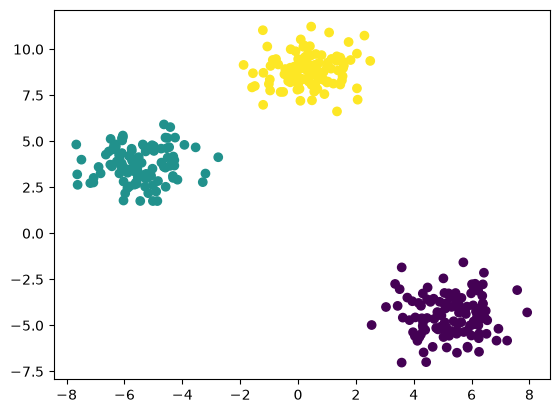

In [15]:
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred)
plt.show()

## Visualize clusters with centroids (Plotly)

In [16]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import plotly.express as px
import plotly.graph_objects as go

In [18]:
# Centroids are in scaled form, convert back to original scale
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids

array([[ 5.17568568, -4.34071879],
       [-5.54566473,  3.71330115],
       [ 0.19425397,  8.9455833 ]])

In [19]:
# Put training data and cluster labels in a DataFrame
df = pd.DataFrame(X_train, columns=["Feature 1", "Feature 2"])
df["Cluster"] = kmeans.labels_.astype(str)

# Scatter plot of clusters
fig = px.scatter(df, x="Feature 1", y="Feature 2", color="Cluster",
                 title="K-Means Clusters with Centroids")

# Add centroids as big black X markers
fig.add_trace(go.Scatter(x=centroids[:, 0], y=centroids[:, 1], mode="markers",
                         marker=dict(symbol="x", size=18, color="black"),
                         name="Centroids"))
fig.show()

## Validating the K value
1. KneeLocator
2. Silhouette score

### KneeLocator

In [20]:
%pip install kneed

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
from kneed import KneeLocator

In [22]:
# Finds the elbow point automatically
kl = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
kl.elbow

np.int64(3)

### Silhouette score

In [23]:
from sklearn.metrics import silhouette_score

In [24]:
# Score ranges from -1 to 1, higher is better (needs K >= 2)
silhouette_coefficients = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled, kmeans.labels_)
    silhouette_coefficients.append(score)

In [25]:
silhouette_coefficients

[0.7095519679981618,
 0.800971096985119,
 0.6422905653524956,
 0.4765070502824249,
 0.33278156197107817,
 0.34419411102005665,
 0.3522801973273204,
 0.3528355933852546,
 0.34654258165471213]

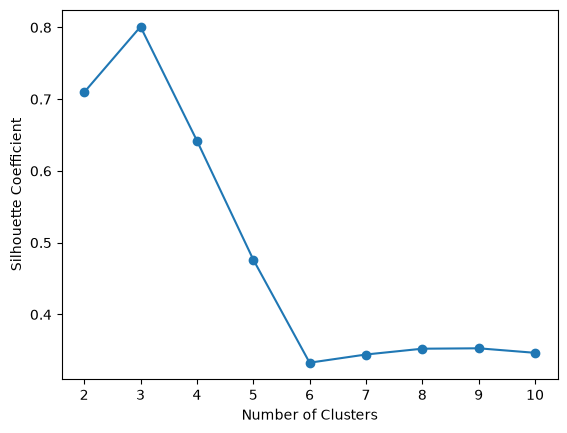

In [26]:
# Plot silhouette scores
plt.plot(range(2, 11), silhouette_coefficients, marker="o")
plt.xticks(range(2, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()